In [2]:
import sys
import os
import pandas as pd
import numpy as np
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from dataset import RepositorioDados
from models.transformer import compute_metrics, evaluate_and_visualize

# Detecta o dispositivo e a precisão usada nas operações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Device: cpu | Precision: torch.float32


In [3]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
FEATURES = ["Vol_lag_1", "Vol_week_mean", "Vol_month_mean"]
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 256         # Janela histórica: x dias passados
FORECAST_HORIZON = 1        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 16            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 0             # Workers para data loading (0 em Windows)
EPOCHS = 50                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 1e-4        # Taxa de aprendizado

D_MODEL = 128              # Dimensão do modelo (embedding)
NUM_ATTENTION_HEADS = 8     # Número de cabeças de atenção
NUM_HIDDEN_LAYERS = 2      # Número de camadas ocultas (reduzido para evitar overfitting)
FFN_DIM = 256              # Dimensão da feedforward network (aumentado para compensar menos camadas)
DROPOUT = 0.1              # Taxa de dropout
ATTENTION_DROPOUT = 0.1
SCALING = False            # Desativar escalonamento (já normalizamos os dados)

In [4]:
repo = RepositorioDados()

In [5]:
tsp, train_ds, valid_ds, test_ds, test_df = repo.executar(
    timestamp_col=TIMESTAMP_COLUMN,
    train_frac=TRAIN_FRAC,
    valid_frac=VALID_FRAC,
    context_length=CONTEXT_LENGTH,
    features=FEATURES,
    target=TARGET_COLUMN,
    id_cols=ID_COLUMNS,
    forecast_horizon=FORECAST_HORIZON
)

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade
Treino: 1534 amostras | Val: 256 | Teste: 512


In [6]:
config = PatchTSTConfig(
    do_mask_input=False,
    context_length=CONTEXT_LENGTH,
    patch_length=PATCH_LENGTH,
    num_input_channels=len(TARGET_COLUMN),
    patch_stride=PATCH_LENGTH,
    prediction_length=FORECAST_HORIZON,
    d_model=D_MODEL,
    num_attention_heads=NUM_ATTENTION_HEADS,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    head_dropout=ATTENTION_DROPOUT,
    pooling_type=None,
    channel_attention=True, # Ativação da atenção entre canais
    loss='mse',
    pre_norm=True,
    norm_type='batchnorm',
)

model = PatchTSTForPrediction(
    config=config
    ).to(device).to(dtype)

In [7]:
train_args = TrainingArguments(
    output_dir="./patchtst_volatility",
    overwrite_output_dir=True,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),
    logging_dir="./logs_patchtst_volatility",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"]
)

early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=0.001
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

In [8]:
print("Iniciando o treinamento do PatchTST para volatilidade...")
trainer.train()

Iniciando o treinamento do PatchTST para volatilidade...


Epoch,Training Loss,Validation Loss,Mse,Mae,Rmse,Mape
1,0.651400,0.035383,0.035383,0.105674,0.188103,75.310504
2,0.600200,0.030419,0.030419,0.081167,0.174410,65.685117
3,0.567500,0.028973,0.028973,0.084483,0.170214,65.033209
4,0.552700,0.027535,0.027535,0.085169,0.165937,58.267069
5,0.537800,0.028201,0.028201,0.084539,0.167932,56.267798
6,0.544700,0.027372,0.027372,0.080653,0.165445,63.416678
7,0.531600,0.027438,0.027438,0.077213,0.165646,55.646718
8,0.543300,0.027350,0.027350,0.081320,0.165379,52.880460
9,0.542200,0.026516,0.026516,0.077572,0.162836,59.694350


TrainOutput(global_step=432, training_loss=0.5634797149234347, metrics={'train_runtime': 33.9785, 'train_samples_per_second': 2257.312, 'train_steps_per_second': 70.633, 'total_flos': 5762628817920.0, 'train_loss': 0.5634797149234347, 'epoch': 9.0})

=== AVALIAÇÃO FINAL – Transformer – From Scratch ===

MSE: 5.680804e-07
MAE: 3.011407e-04
RMSE: 7.537111e-04
MAPE: 5.581836e+01


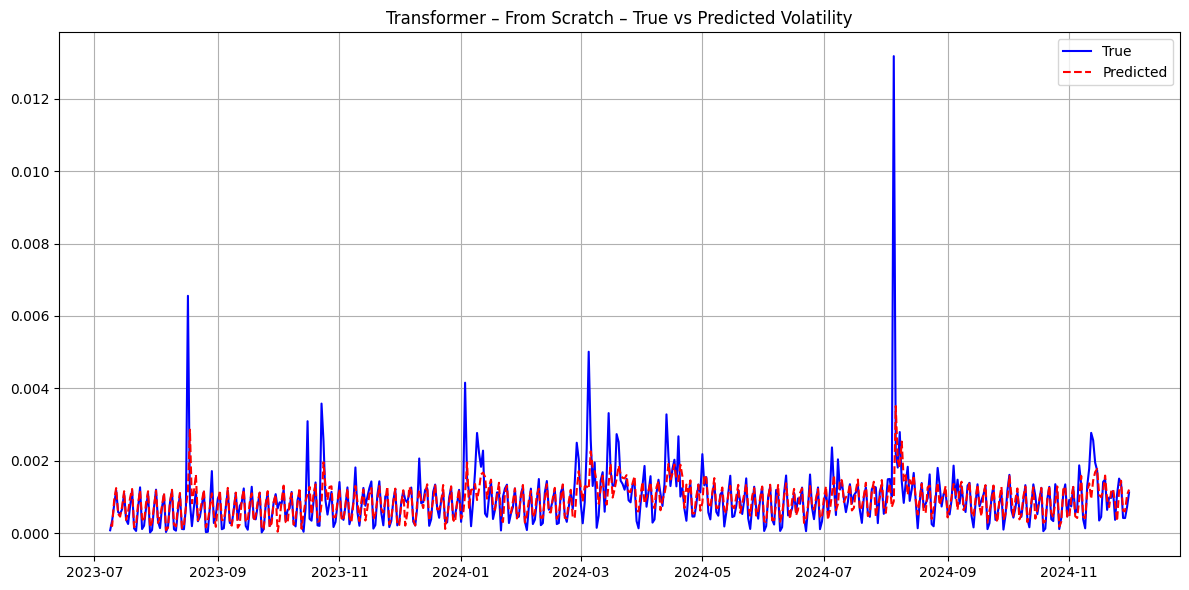

In [11]:
forecast_dates_scratch, results_scratch = evaluate_and_visualize(
    model,
    test_ds,
    tsp,
    test_df,
    model_name="Transformer – From Scratch",
    timestamp_col=TIMESTAMP_COLUMN,
    context_lenght=CONTEXT_LENGTH,
    batch_size=BATCH_SIZE
)